# Deliverable 2: Initial information

This notebook contains the fixed initial information for the spatial search problem.

You are given:

- the fixed search grid,
- the environmental dataset associated with each cell,
- the location of the accident,
- the main physical vectors involved in the event,
- and two qualitative witness statements.

Your task is to use this information to construct a prior distribution over the grid, define a detection model, update your beliefs after search missions, and propose a new mission.

## Fixed grid

The search region is represented by a fixed rectangular grid with dimensions

$$
N_x = 50, \qquad N_y = 35.
$$

Each valid cell is identified by a unique `cell_id` and is described by the coordinates of its center together with two environmental variables:

- `depth`
- `roughness`

These data are provided in the file `grid_dataset.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Grid dimensions
Nx = 50
Ny = 35

# Load the fixed grid dataset
grid_df = pd.read_csv("grid_dataset.csv")

grid_df.head()


,cell_id,x,y,depth,roughness
0,0,0.5,0.5,0.000000,0.387418
1,1,1.5,0.5,0.037815,0.379730
2,2,2.5,0.5,0.075630,0.389246
3,3,3.5,0.5,0.113445,0.399845
4,4,4.5,0.5,0.151261,0.378569


## Accident location

The aircraft accident is assumed to take place at the grid location

$$
(x_E, y_E) = (7, 20).
$$

This point should be interpreted as the reference location from which the subsequent spatial displacement of the object begins.

In [2]:
Bx = 7
By = 20

x_E = np.array([Bx, By])
x_E

array([ 7, 20])

## Physical vectors

The following vectors describe the main physical effects involved in the event.

### Aircraft velocity
The aircraft velocity vector is

$$
v_{\text{plane}} = (6.0, -3.5).
$$

This corresponds to a motion that is mostly eastward, with a slight southward component.

### Wind
The wind vector is

$$
v_{\text{wind}} = (-1.0, -1.5).
$$

This corresponds to a motion that is mostly westward, with a slight southward component.

### Water drift
The water drift vector is

$$
v_{\text{drift}} = (0.5, -1.5).
$$

This corresponds to a motion that is slightly eastward, with a stronger southward component.

In [3]:
v_plane = np.array([6.0, -3.5])
v_wind  = np.array([-1.0, -1.5])
v_drift = np.array([0.5, -1.5])

print("Accident location:", x_E)
print("Plane velocity:", v_plane)
print("Wind:", v_wind)
print("Drift:", v_drift)

Accident location: [ 7 20]
Plane velocity: [ 6.  -3.5]
Wind: [-1.  -1.5]
Drift: [ 0.5 -1.5]


## Witness statements

You may also use the following qualitative witness statements.

### Witness 1
A distant witness reported that, after the explosion, the object seemed to keep moving forward, roughly following the general direction of the aircraft.

### Witness 2
A second observer, who had a slightly better view of the event, stated that the object appeared to fall into the sea somewhat farther along the trajectory and slightly off to one side of the main path.

These statements are intentionally vague. You may decide how much weight to give them, or whether to use them at all, but any choice must be justified.

## What is fixed and what is not

The following elements are fixed:

- the grid dimensions,
- the cell-level dataset,
- the accident location,
- the physical vectors,
- the search cost rule,
- the binary coverage rule.

However, the following elements must be modeled by you:

- the prior distribution over the grid,
- the conditional detectability term,
- the likelihood and posterior update,
- the strategy for proposing a new search mission.

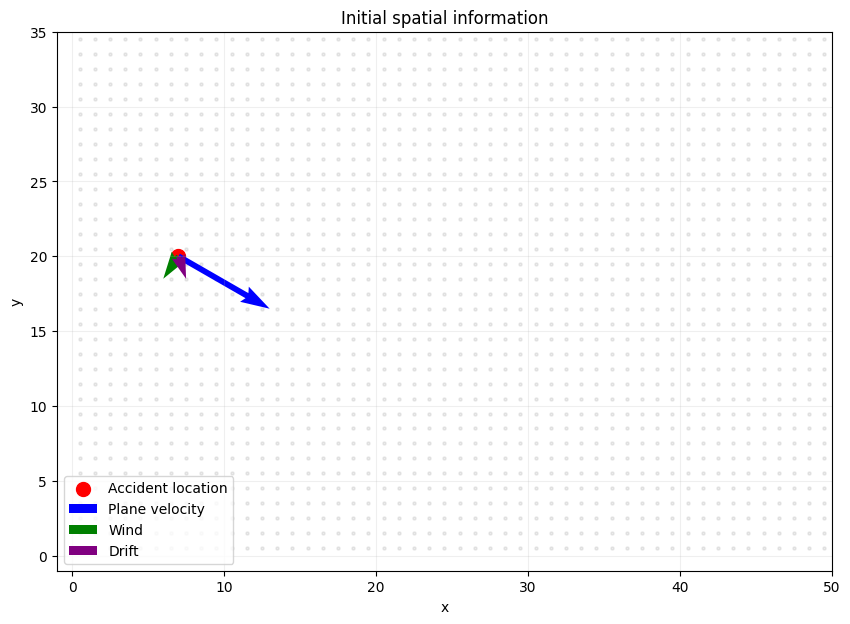

In [4]:
plt.figure(figsize=(10, 7))

# Plot grid points lightly
plt.scatter(grid_df["x"], grid_df["y"], s=5, alpha=0.15, color="gray")

# Accident location
plt.scatter(x_E[0], x_E[1], color="red", s=100, label="Accident location")

# Vectors
plt.quiver(x_E[0], x_E[1], v_plane[0], v_plane[1], angles="xy", scale_units="xy", scale=1, color="blue", label="Plane velocity")
plt.quiver(x_E[0], x_E[1], v_wind[0], v_wind[1], angles="xy", scale_units="xy", scale=1, color="green", label="Wind")
plt.quiver(x_E[0], x_E[1], v_drift[0], v_drift[1], angles="xy", scale_units="xy", scale=1, color="purple", label="Drift")

plt.xlim(-1, Nx)
plt.ylim(-1, Ny)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Initial spatial information")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Final remark

The information in this notebook is intentionally incomplete from a modeling perspective. The goal is not to apply a fully specified model, but to construct one in a coherent and well-justified way using the available information.